# Inspect training metrics

Plot **every** metric stored in a Lightning `CSVLogger` `metrics.csv`, for a
**pretraining** run and a **finetuning / from-scratch** run.

The CSV is sparse: step-level metrics (`lr-*`, `*_step`) and epoch-level
metrics (`val_*`, `*_epoch`, `mem/*`) are logged on different rows, so most
cells are empty. We keep the file as-is and drop NaNs per metric at plot time.

Run this notebook from the `slurm/` directory (where it lives).

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Locate the runs

In [2]:
# This notebook lives in slurm/. Resolve that directory whether it is launched
# from slurm/ or from the repo root.
SLURM_DIR = Path.cwd()
if SLURM_DIR.name != 'slurm' and (SLURM_DIR / 'slurm').is_dir():
    SLURM_DIR = SLURM_DIR / 'slurm'
assert SLURM_DIR.is_dir(), f'Could not find the slurm directory (cwd={Path.cwd()})'


def find_metrics(must_contain: str) -> Path:
    '''Most recently modified metrics.csv whose path contains must_contain
    (searched recursively under SLURM_DIR).'''
    candidates = sorted(
        (p for p in SLURM_DIR.glob('**/metrics.csv') if must_contain in str(p)),
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f'No metrics.csv containing {must_contain!r} under {SLURM_DIR}'
        )
    return candidates[-1]


# Auto-pick the latest run of each kind. To pin a specific run, set the path
# explicitly, e.g.:
#   PRETRAIN_METRICS = SLURM_DIR / 'pretraining/run_xxx/model_0_colrow/version_0/metrics.csv'
PRETRAIN_METRICS = find_metrics('pretraining')
FINETUNE_METRICS = find_metrics('classify_from_scratch')

print('pretrain:', PRETRAIN_METRICS.relative_to(SLURM_DIR))
print('finetune:', FINETUNE_METRICS.relative_to(SLURM_DIR))

pretrain: pretraining/run_20260619_095748/model_0_colrow/version_0/metrics.csv
finetune: classify_from_scratch/run_20260618_120934/model_0_colrow/version_0/metrics.csv


## Helpers

In [ ]:
def load_metrics(path) -> pd.DataFrame:
    '''Load a Lightning CSVLogger metrics.csv as-is (sparse).'''
    return pd.read_csv(path)


def base_name(col: str) -> str:
    '''Grouping key: strip a train_/val_/test_ prefix and a _step/_epoch suffix
    so that e.g. train_loss_epoch, train_loss_step and val_loss share one axis.'''
    b = col
    for p in ('train_', 'val_', 'test_'):
        if b.startswith(p):
            b = b[len(p):]
            break
    for s in ('_epoch', '_step'):
        if b.endswith(s):
            b = b[: -len(s)]
    return b


def metric_columns(df: pd.DataFrame) -> list:
    '''Numeric metric columns that actually contain data (drop index cols).'''
    return [c for c in df.columns if c not in ('epoch', 'step') and df[c].notna().any()]


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    '''One row per metric: number of points and first/last/min/max value.'''
    rows = []
    for c in metric_columns(df):
        s = df[c].dropna()
        rows.append(dict(metric=c, n=len(s), first=s.iloc[0], last=s.iloc[-1],
                         min=s.min(), max=s.max()))
    return pd.DataFrame(rows).set_index('metric')


def plot_metrics(df: pd.DataFrame, run_name: str = '', x: str = 'step',
                 ncols: int = 3, logy: bool = False):
    '''Plot every metric. train_/val_ variants of the same quantity are drawn on
    a shared subplot (val_* dashed) so train/val are easy to compare.'''
    groups = {}
    for c in metric_columns(df):
        groups.setdefault(base_name(c), []).append(c)

    names = sorted(groups)
    nrows = math.ceil(len(names) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows),
                             squeeze=False)
    axes = axes.flatten()

    for ax, name in zip(axes, names):
        members = sorted(groups[name])
        for col in members:
            s = df[[x, col]].dropna().sort_values(x)
            if s.empty:
                continue
            style = '--' if col.startswith('val_') else '-'
            ax.plot(s[x], s[col], style, marker='.', ms=3, lw=1.3, label=col)
        ax.set_title(members[0] if len(members) == 1 else name)
        ax.set_xlabel(x)
        if logy:
            ax.set_yscale('log')
        if len(members) > 1:
            ax.legend(fontsize=8)
    for ax in axes[len(names):]:
        ax.axis('off')

    if run_name:
        fig.suptitle(run_name, fontsize=14)
    fig.tight_layout()
    return fig


def plot_selected(df: pd.DataFrame, metrics, run_name: str = '', ncols: int = 2,
                  x: str = 'step', logy: bool = False):
    '''Plot specific metrics, always overlaying the train_ AND val_ variants that
    are present (val_* dashed). Accepts full names (val_loss_ce) or bare bases
    (loss_ce); requests that collapse to the same base share one subplot.
    Metrics absent from this file are reported and skipped, never fatal.'''
    bases = list(dict.fromkeys(base_name(m) for m in metrics))
    cols_by_base = {}
    for b in bases:
        cols = sorted(c for c in df.columns
                      if base_name(c) == b and df[c].notna().any())
        if cols:
            cols_by_base[b] = cols
    missing = [b for b in bases if b not in cols_by_base]
    if missing:
        print('not present in', run_name or 'this run', '->', missing)
    if not cols_by_base:
        return None

    present = list(cols_by_base)
    nrows = math.ceil(len(present) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows),
                             squeeze=False)
    axes = axes.flatten()
    for ax, b in zip(axes, present):
        for col in cols_by_base[b]:
            s = df[[x, col]].dropna().sort_values(x)
            style = '--' if col.startswith('val_') else '-'
            ax.plot(s[x], s[col], style, marker='.', ms=3, lw=1.4, label=col)
        ax.set_title(b)
        ax.set_xlabel(x)
        if logy:
            ax.set_yscale('log')
        ax.legend(fontsize=8)
    for ax in axes[len(present):]:
        ax.axis('off')

    if run_name:
        fig.suptitle(run_name, fontsize=14)
    fig.tight_layout()
    return fig

## Pretraining run

In [4]:
pretrain = load_metrics(PRETRAIN_METRICS)
print('run:', PRETRAIN_METRICS.parents[2].name, '| shape:', pretrain.shape)
print('metrics:', metric_columns(pretrain))
pretrain.head()

run: run_20260619_095748 | shape: (24, 7)
metrics: ['lr-AdamW', 'mem/cpu_rss_MiB', 'mem/gpu_alloc_MiB', 'mem/gpu_reserved_MiB', 'train_loss_step']


,epoch,lr-AdamW,mem/cpu_rss_MiB,mem/gpu_alloc_MiB,mem/gpu_reserved_MiB,step,train_loss_step
0,NaN,0.000001,NaN,NaN,NaN,99,NaN
1,0.0,NaN,2836.503906,187.028320,2972.0,99,20.733349
2,NaN,0.000001,NaN,NaN,NaN,199,NaN
3,0.0,NaN,2848.589844,185.756836,6522.0,199,20.271461
4,NaN,0.000001,NaN,NaN,NaN,299,NaN


In [5]:
summarize(pretrain)

,n,first,last,min,max
metric,,,,,
lr-AdamW,12,0.000001,0.000002,0.000001,0.000002
mem/cpu_rss_MiB,12,2836.503906,2873.617188,2836.503906,2873.617188
mem/gpu_alloc_MiB,12,187.028320,185.903809,185.352051,188.284180
mem/gpu_reserved_MiB,12,2972.000000,17530.000000,2972.000000,17530.000000
train_loss_step,12,20.733349,17.772724,17.772724,20.733349


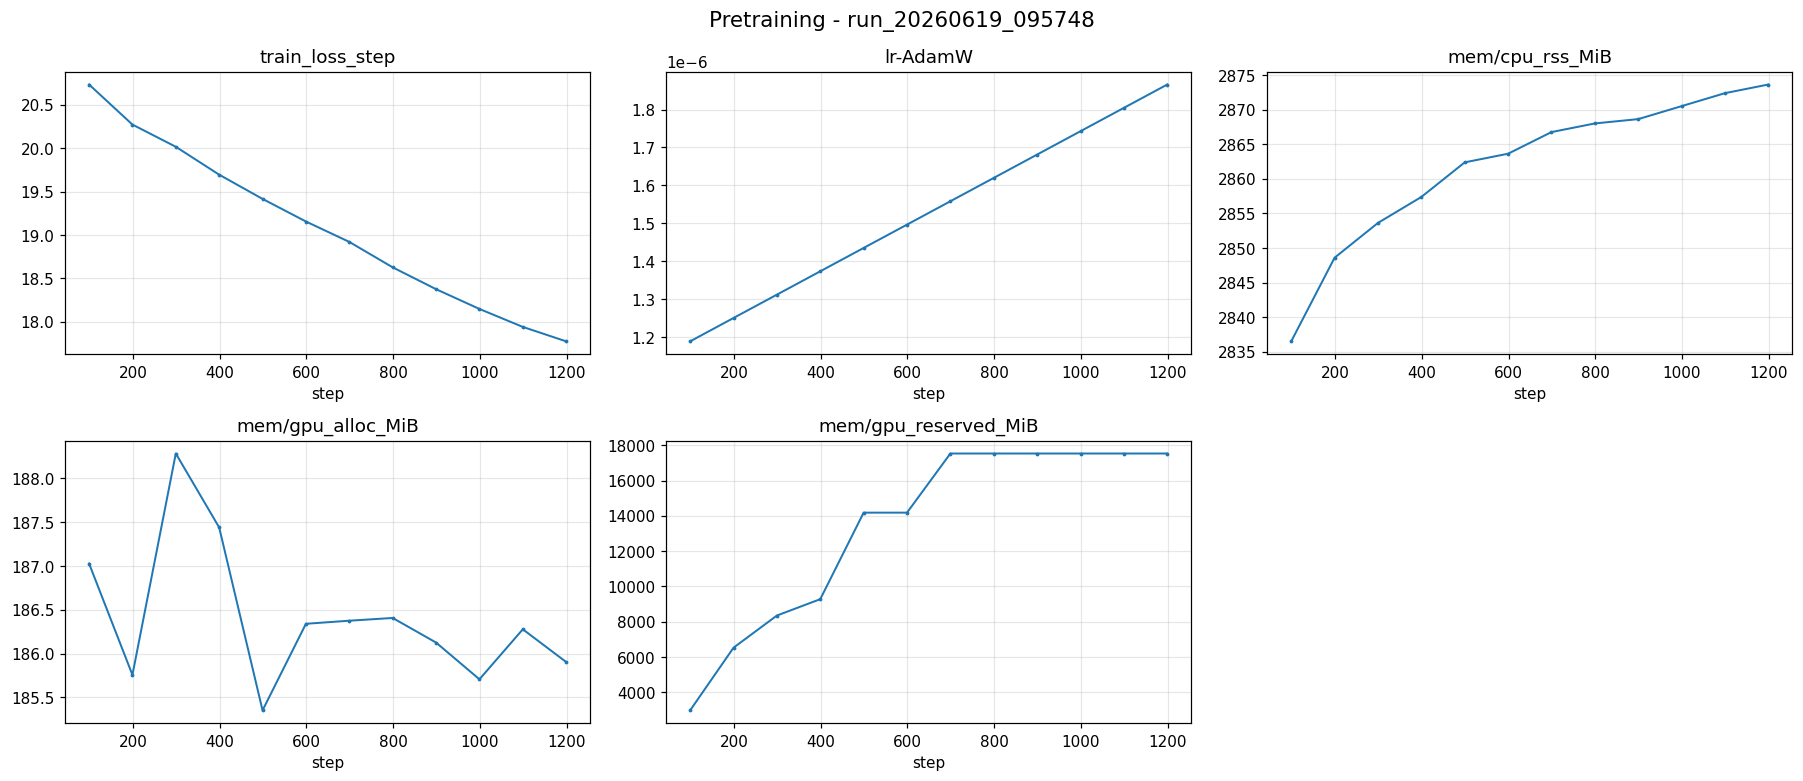

In [11]:
plot_metrics(pretrain, run_name='Pretraining - ' + PRETRAIN_METRICS.parents[2].name)
plt.show()

## Finetuning / from-scratch run

In [7]:
finetune = load_metrics(FINETUNE_METRICS)
print('run:', FINETUNE_METRICS.parents[2].name, '| shape:', finetune.shape)
print('metrics:', metric_columns(finetune))
finetune.head()

run: run_20260618_120934 | shape: (6094, 21)
metrics: ['lr-AdamW/pg1', 'lr-AdamW/pg2', 'mem/cpu_rss_MiB', 'mem/gpu_alloc_MiB', 'mem/gpu_reserved_MiB', 'train_acc', 'train_jet_embedding/loss_contrastive', 'train_loss_ce', 'train_loss_epoch', 'train_loss_step', 'val_acc', 'val_auroc', 'val_jet_embedding/loss_contrastive', 'val_jets/effective_rank', 'val_jets/uniformity', 'val_loss', 'val_loss_ce', 'val_tracks/effective_rank', 'val_tracks/uniformity']


,epoch,lr-AdamW/pg1,lr-AdamW/pg2,mem/cpu_rss_MiB,mem/gpu_alloc_MiB,mem/gpu_reserved_MiB,step,train_acc,train_jet_embedding/loss_contrastive,train_loss_ce,...,train_loss_step,val_acc,val_auroc,val_jet_embedding/loss_contrastive,val_jets/effective_rank,val_jets/uniformity,val_loss,val_loss_ce,val_tracks/effective_rank,val_tracks/uniformity
0,NaN,1.107917e-07,0.000001,NaN,NaN,NaN,99,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,2869.667969,187.354492,3740.0,99,NaN,NaN,NaN,...,3.852746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1.216924e-07,0.000001,NaN,NaN,NaN,199,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,NaN,2888.906250,186.463867,4022.0,199,NaN,NaN,NaN,...,3.767564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,1.325930e-07,0.000001,NaN,NaN,NaN,299,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
summarize(finetune)

,n,first,last,min,max
metric,,,,,
lr-AdamW/pg1,3014,1.107917e-07,0.000008,1.107917e-07,0.000010
lr-AdamW/pg2,3014,1.250211e-06,0.000095,1.250211e-06,0.000113
mem/cpu_rss_MiB,3047,2.869668e+03,3748.792969,2.401400e+03,3748.808594
mem/gpu_alloc_MiB,3047,1.873545e+02,186.055176,1.606859e+02,188.759277
mem/gpu_reserved_MiB,3047,3.740000e+03,4396.000000,3.740000e+03,4396.000000
train_acc,33,6.298988e-01,0.732210,6.298988e-01,0.732210
train_jet_embedding/loss_contrastive,33,7.372359e+00,5.302496,5.302496e+00,7.372359
train_loss_ce,33,8.933600e-01,0.654104,6.541043e-01,0.893360
train_loss_epoch,33,3.105070e+00,2.244853,2.244853e+00,3.105070


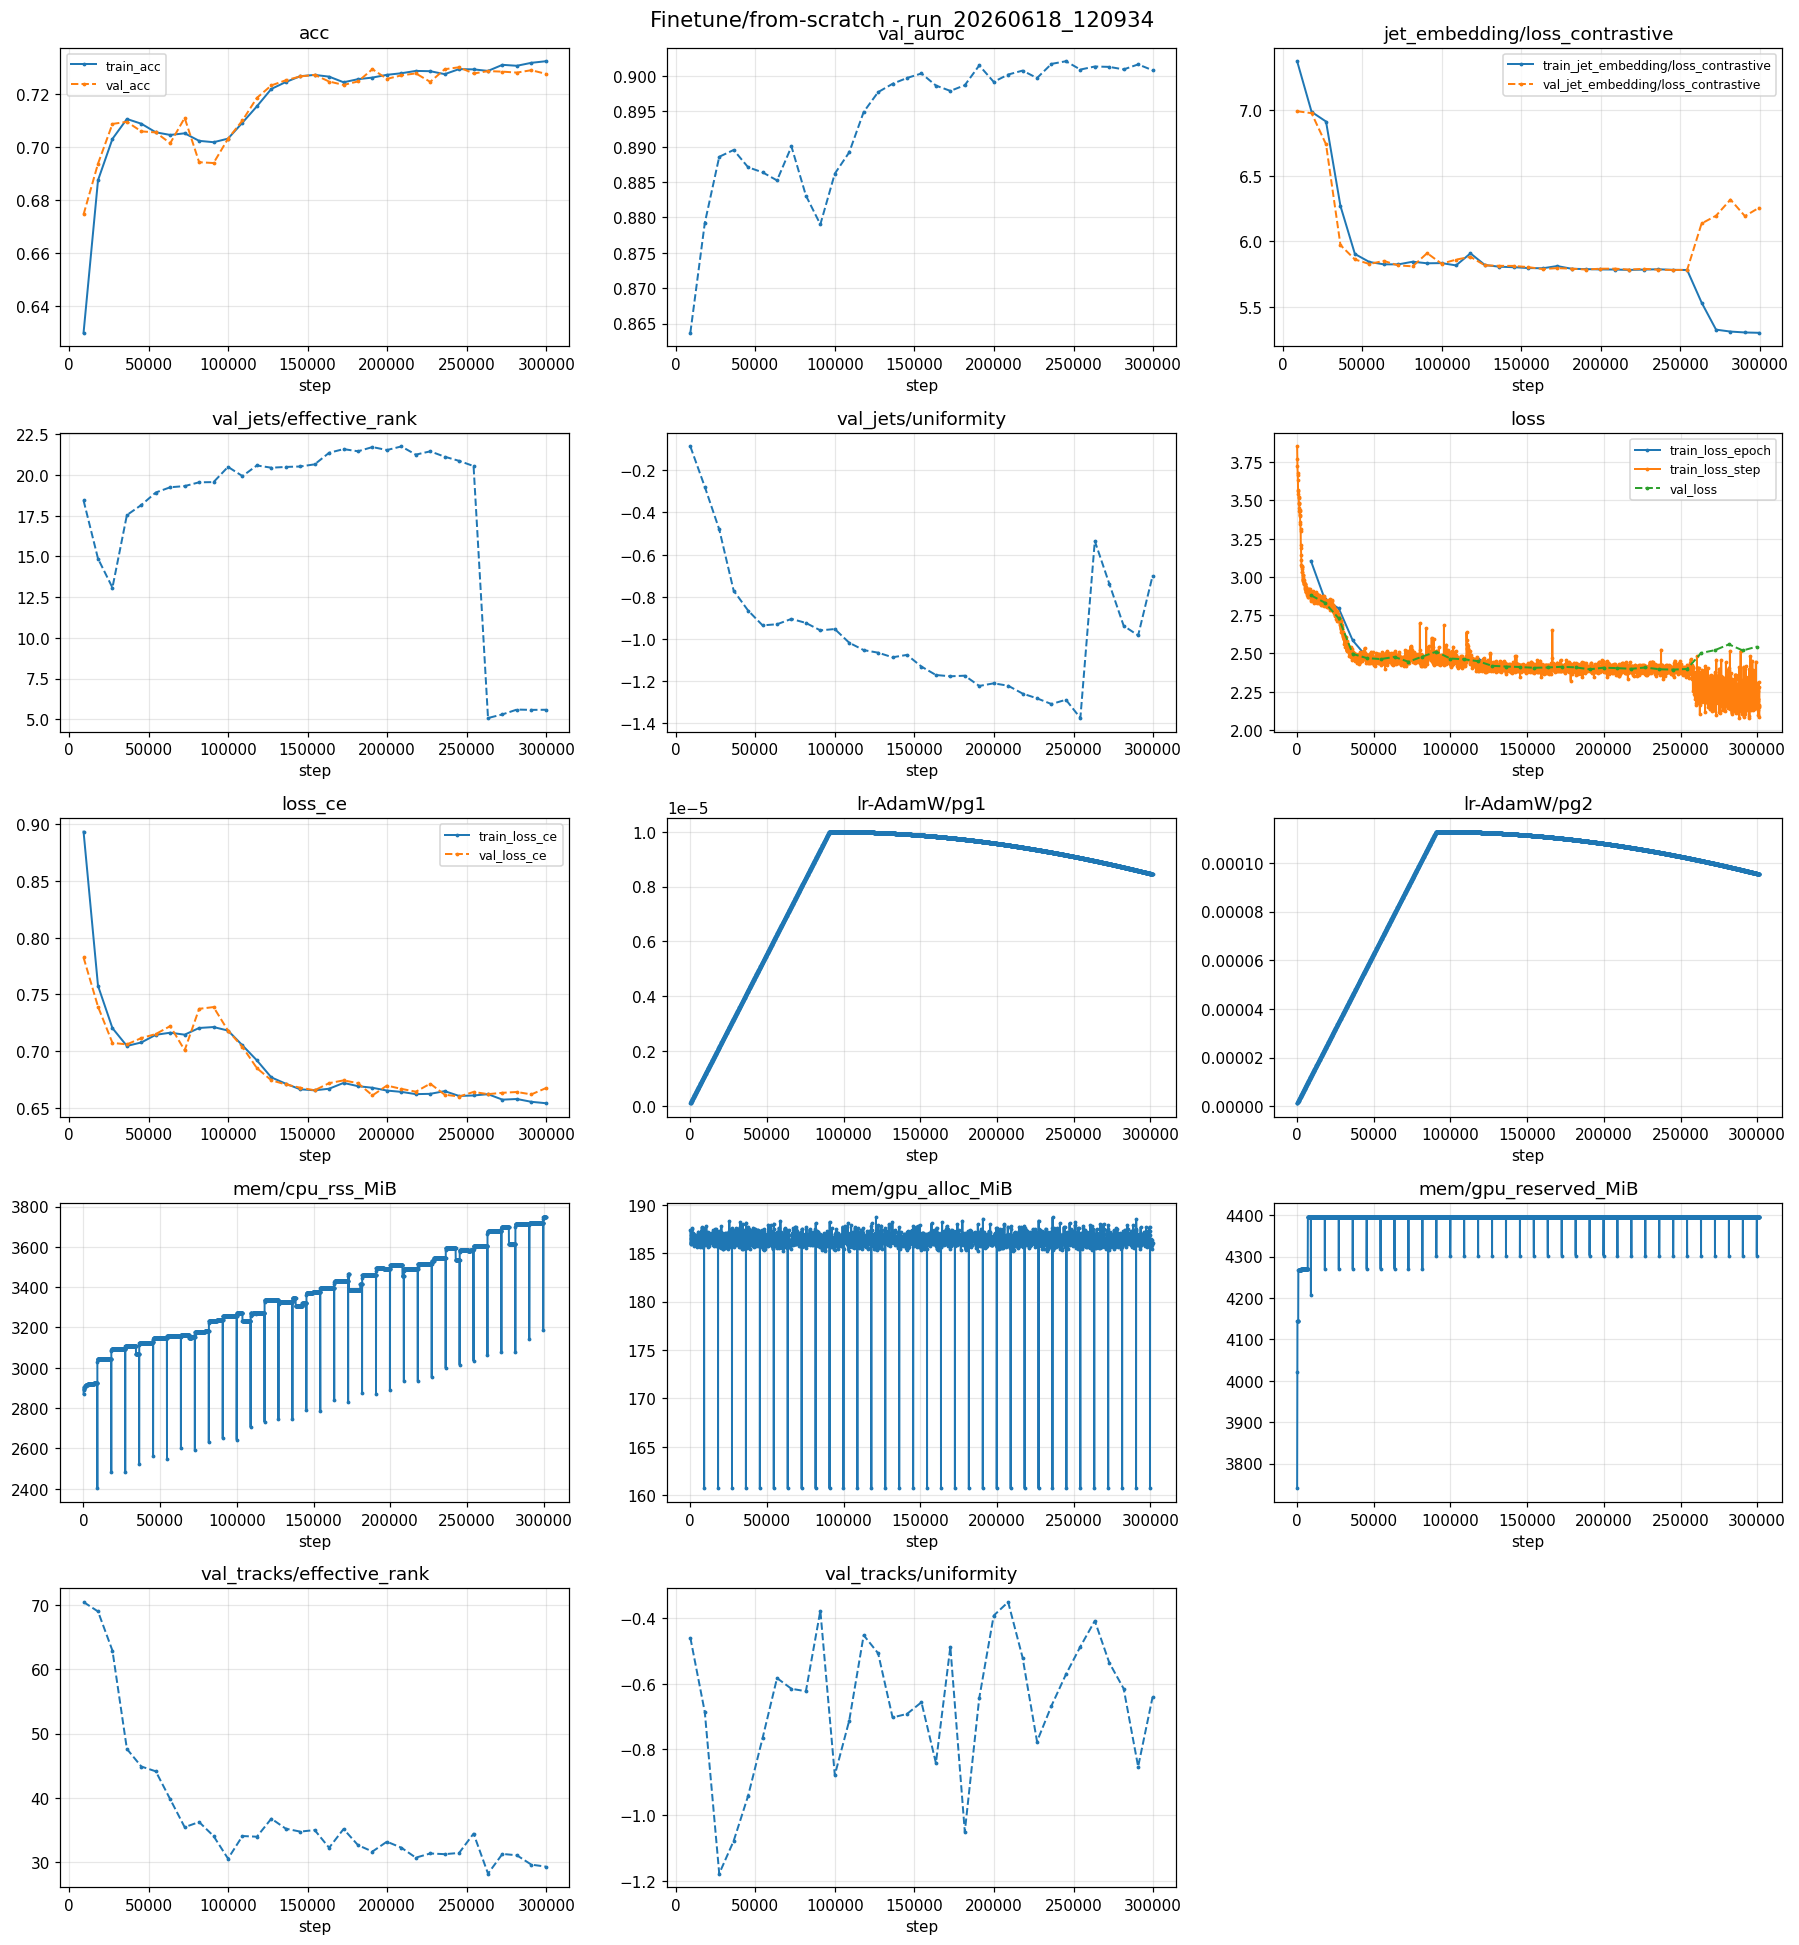

In [14]:
plot_metrics(finetune, run_name='Finetune/from-scratch - ' + FINETUNE_METRICS.parents[2].name, x='step')
plt.show()

## Focus metrics

Specific probes called out for inspection:

- `val_tracks/effective_rank` and `val_tracks/uniformity`
- `val_jet_embedding/loss_contrastive`
- cross-entropy loss (`loss_ce`)

For each, **both the train and val variants are overlaid whenever present**
(val dashed). Anything missing from a given run is reported and skipped. Edit
`FOCUS_METRICS` to add/remove probes.

In [ ]:
FOCUS_METRICS = [
    'val_tracks/effective_rank',
    'val_tracks/uniformity',
    'val_jet_embedding/loss_contrastive',
    'val_loss_ce',  # cross-entropy; the train_ sibling is overlaid automatically
]

In [ ]:
plot_selected(finetune, FOCUS_METRICS,
              run_name='Finetune/from-scratch - ' + FINETUNE_METRICS.parents[2].name)
plt.show()

In [ ]:
plot_selected(pretrain, FOCUS_METRICS,
              run_name='Pretraining - ' + PRETRAIN_METRICS.parents[2].name)
plt.show()

### Notes / tips
- `plot_metrics(df, x='step')` is the default. For epoch-aligned metrics you can
  also pass `x='epoch'` (step-only series such as `train_loss_step` then drop out).
- `plot_selected(df, ['val_loss_ce', ...])` plots a chosen subset and always
  overlays the train/val pair when present — see the *Focus metrics* section.
- Pass `logy=True` for a log y-axis, handy for loss curves with a large range.
- `summarize(df)` gives the best (min/max) and final value of every metric, e.g.
  the best `val_loss` / `val_auroc` of the finetune run.
- Point either run at a specific directory by setting `PRETRAIN_METRICS` /
  `FINETUNE_METRICS` explicitly in the *Locate the runs* cell.